**Перед выполнением ячеек переключесь на среду с графическим процессором.**

# 🧪 Практическое занятие: Transfer Learning (дообучение нейросети) на классах, отсутствующих в ImageNet

**Цель работы:** Научиться применять Transfer Learning для решения задачи классификации изображений с использованием предобученной модели. Мы загрузим модель ResNet-18, обученную на ImageNet, и дообучим (fine-tune) её для классификации двух классов из датасета **MNIST**: цифры **0** и **1**. Эти классы **отсутствуют в ImageNet**, что позволит наглядно продемонстрировать эффективность переноса признаков даже на совершенно новые данные.

**План:**
1. Загрузка и подготовка данных (MNIST, только цифры 0 и 1)
2. Преобразование одноканальных изображений в трёхканальные для подачи в ResNet
3. Загрузка предобученной модели и замена последнего слоя
4. Обучение только нового классификатора (feature extractor)
5. Дообучение всей сети (fine-tuning) с уменьшенной скоростью обучения
6. Сравнение результатов с обучением с нуля
7. Визуализация результатов и выводы

**Задача**: в примерах ниже точность почти сразу становится равной 1. Попробовать либо доавить все цифры, не только 0 и 1, либо взять вообще какой-нибудь более сложный набор данных.

## 1. Импортируем необходимые библиотеки

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import copy
import os
import random

# Установка seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')

Используется устройство: cuda


## 2. Подготовка данных

Мы используем датасет MNIST, но оставим только два класса: цифры **0** и **1**. Для подачи в ResNet, который ожидает трёхканальные изображения размером 224×224, мы преобразуем одноканальные изображения в трёхканальные путём копирования канала и применим ресайз.

In [9]:
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]

        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

In [13]:
# Определяем трансформации для train и val
train_transform = transforms.Compose([
    transforms.Resize(224),                     # увеличиваем до 224x224
    transforms.Grayscale(num_output_channels=3),# конвертируем 1 канал в 3 (повторяем)
    transforms.RandomHorizontalFlip(),          # аугментация: случайное отражение (для цифр может быть неестественно, но оставим)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загружаем MNIST
train_full = datasets.MNIST(root='./data', train=True, download=True)
test_full = datasets.MNIST(root='./data', train=False, download=True)

# Индексы классов: 0 и 1
selected_classes = [0, 1]
train_indices = [i for i, (_, label) in enumerate(train_full) if label in selected_classes]
test_indices = [i for i, (_, label) in enumerate(test_full) if label in selected_classes]

# Создаём подмножества
train_dataset = ApplyTransform(Subset(train_full, train_indices), train_transform)
test_dataset = ApplyTransform(Subset(test_full, test_indices), test_transform)

# Преобразуем метки: 0→0, 1→1 (они и так 0 и 1)
# Но можно оставить как есть, поскольку Subset сохраняет исходные метки.

# Создаём загрузчики
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f'Размер обучающей выборки (0 и 1): {len(train_dataset)}')
print(f'Размер тестовой выборки (0 и 1): {len(test_dataset)}')

Размер обучающей выборки (0 и 1): 12665
Размер тестовой выборки (0 и 1): 2115


**TODO для опытных**: Изменить порядок обработки так, чтобы графические преобразования не применялись к цифрам 2,3,4... (только к 0 и 1).

Сделал

## 3. Загрузка предобученной модели и замена последнего слоя

Загрузим ResNet-18 с весами ImageNet. Заменим последний полносвязный слой (`model.fc`) на новый, соответствующий нашей задаче (2 класса).

In [14]:
from torchvision.models.resnet import ResNet18_Weights
# Загружаем предобученный ResNet-18
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Замораживаем все слои (для начала будем обучать только последний)
for param in model.parameters():
    param.requires_grad = False

# Получаем размер входа последнего слоя
num_features = model.fc.in_features
# Создаём новый классификатор
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

# Выведем структуру модели (последние слои)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 4. Функции для обучения и оценки

In [15]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc='Обучение', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Оценка', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs+1):
        print(f'\nЭпоха {epoch}/{epochs}')
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
        print(f'Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}')

        if scheduler:
            scheduler.step()

        # Сохраняем лучшую модель
        if test_acc > best_acc:
            best_acc = test_acc
            best_weights = copy.deepcopy(model.state_dict())

    print(f'\nЛучшая точность на тесте: {best_acc:.4f}')
    model.load_state_dict(best_weights)
    return model, history

## 5. Этап 1: Обучение только нового классификатора (Feature Extractor)

Сначала обучим только последний слой, оставив остальные замороженными. Это позволит быстро получить базовое качество и проверить, насколько хорошо предобученные признаки (из ImageNet) подходят для распознавания рукописных цифр.

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer_fe = optim.Adam(model.fc.parameters(), lr=1e-3)

# Замораживаем все слои
for param in model.parameters():
    param.requires_grad = False

# Размораживаем только последний слой (классификатор)
for param in model.fc.parameters():
    param.requires_grad = True

model_fe, history_fe = train_model(model, train_loader, test_loader, criterion, optimizer_fe, epochs=5)


Эпоха 1/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0510 Acc: 0.9871
Test Loss: 0.0109 Acc: 0.9981

Эпоха 2/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0083 Acc: 0.9978
Test Loss: 0.0051 Acc: 0.9981

Эпоха 5/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0089 Acc: 0.9970
Test Loss: 0.0023 Acc: 0.9995

Лучшая точность на тесте: 0.9995


## 6. Этап 2: Дообучение всей сети (Fine-Tuning)

Теперь разморозим все слои и продолжим обучение с маленькой скоростью обучения, чтобы аккуратно подстроить веса под новые данные (цифры).

In [20]:
print(list(k for k, v in model.named_parameters()))

['conv1.weight', 'bn1.weight', 'bn1.bias', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.conv2.weight', 'layer2.0.bn2.weight', 'layer2.0.bn2.bias', 'layer2.0.downsample.0.weight', 'layer2.0.downsample.1.weight', 'layer2.0.downsample.1.bias', 'layer2.1.conv1.weight', 'layer2.1.bn1.weight', 'layer2.1.bn1.bias', 'layer2.1.conv2.weight', 'layer2.1.bn2.weight', 'layer2.1.bn2.bias', 'layer3.0.conv1.weight', 'layer3.0.bn1.weight', 'layer3.0.bn1.bias', 'layer3.0.conv2.weight', 'layer3.0.bn2.weight', 'layer3.0.bn2.bias', 'layer3.0.downsample.0.weight', 'layer3.0.downsample.1.weight', 'layer3.0.downsample.1.bias', 'layer3.1.conv1.weight', 'layer3.1.bn1.weight', 'layer3.1.bn1.bias', 'layer3.1.

In [26]:
# Размораживаем все слои
for param in model.parameters():
    param.requires_grad = True

# Параметры всех слоёв кроме того, который называется "fc" (последний)
base_params = [p for name, p in model.named_parameters() if 'fc' not in name]
basicblock41_params = [p for name, p in model.named_parameters() if 'layer4.1' in name]
print(type(basicblock41_params), len(basicblock41_params))

# Используем маленькую скорость обучения для предобученных слоёв
optimizer_ft = optim.Adam([
    {'params': model.fc.parameters(), 'lr': 1e-3},       # большая для классификатора
    {'params': basicblock41_params, 'lr':1e-4}
], lr=1e-5)

# Планировщик делает разную скорость для разных эпох, это к Fine-Tuning отношения не имеет.
# Добавим scheduler для плавного уменьшения LR
# step_size - количество эпох внутри одного этапа обучения.
# gamma - множитель изменения скорости обучения между этапами обучения.
# scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=3, gamma=0.1)

model_ft, history_ft = train_model(model, train_loader, test_loader, criterion, optimizer_ft, epochs=5)

<class 'list'> 6

Эпоха 1/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0021 Acc: 0.9997
Test Loss: 0.0005 Acc: 0.9995

Эпоха 2/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0000 Acc: 1.0000
Test Loss: 0.0000 Acc: 1.0000

Эпоха 5/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0014 Acc: 0.9998
Test Loss: 0.0002 Acc: 1.0000

Лучшая точность на тесте: 1.0000


**Задача**: спросить у LLM, как задать индивидуальную скорость обучения для layer4.1.BasicBlock, который идёт последним перед avgpool и fc, попробовать обучить сеть, сравнить результаты.

Сделал

## 7. Сравнение результатов: Feature Extractor vs Fine-Tuning

Построим графики потерь и точности для обеих стратегий.

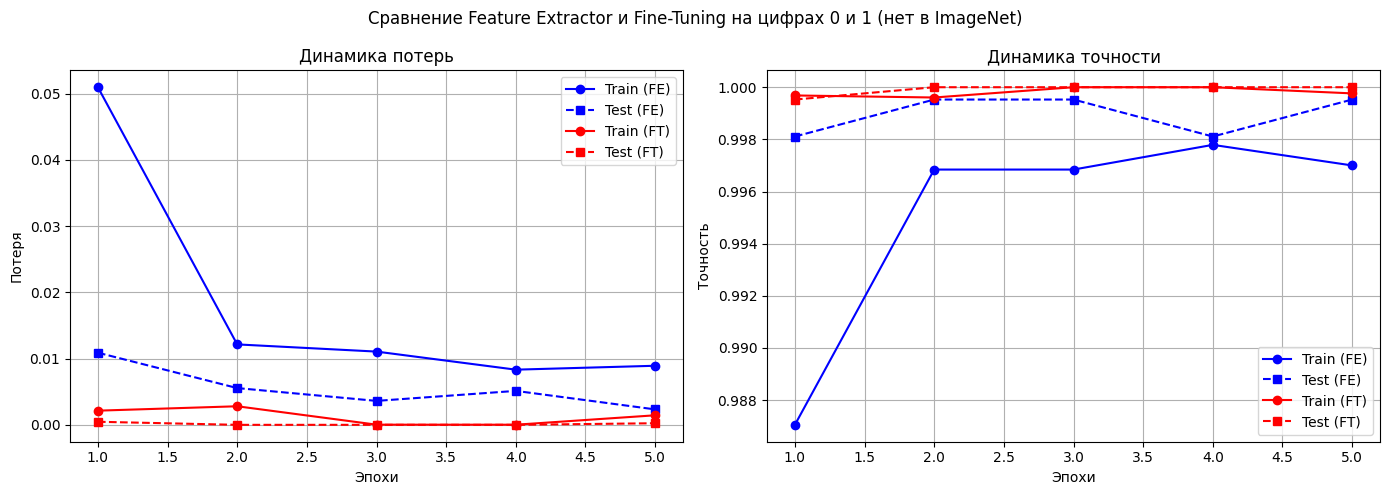

Лучшая точность Feature Extractor: 0.9995
Лучшая точность Fine-Tuning: 1.0000


In [27]:
def plot_history(hist_fe, hist_ft, title):
    epochs_fe = range(1, len(hist_fe['train_loss'])+1)
    epochs_ft = range(1, len(hist_ft['train_loss'])+1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_fe, hist_fe['train_loss'], 'b-o', label='Train (FE)')
    plt.plot(epochs_fe, hist_fe['test_loss'], 'b--s', label='Test (FE)')
    plt.plot(epochs_ft, hist_ft['train_loss'], 'r-o', label='Train (FT)')
    plt.plot(epochs_ft, hist_ft['test_loss'], 'r--s', label='Test (FT)')
    plt.xlabel('Эпохи')
    plt.ylabel('Потеря')
    plt.title('Динамика потерь')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs_fe, hist_fe['train_acc'], 'b-o', label='Train (FE)')
    plt.plot(epochs_fe, hist_fe['test_acc'], 'b--s', label='Test (FE)')
    plt.plot(epochs_ft, hist_ft['train_acc'], 'r-o', label='Train (FT)')
    plt.plot(epochs_ft, hist_ft['test_acc'], 'r--s', label='Test (FT)')
    plt.xlabel('Эпохи')
    plt.ylabel('Точность')
    plt.title('Динамика точности')
    plt.legend()
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_fe, history_ft, 'Сравнение Feature Extractor и Fine-Tuning на цифрах 0 и 1 (нет в ImageNet)')

print(f"Лучшая точность Feature Extractor: {max(history_fe['test_acc']):.4f}")
print(f"Лучшая точность Fine-Tuning: {max(history_ft['test_acc']):.4f}")

## 8. Визуализация предсказаний на тестовых изображениях

Посмотрим, как наша дообученная модель справляется с реальными картинками цифр 0 и 1.

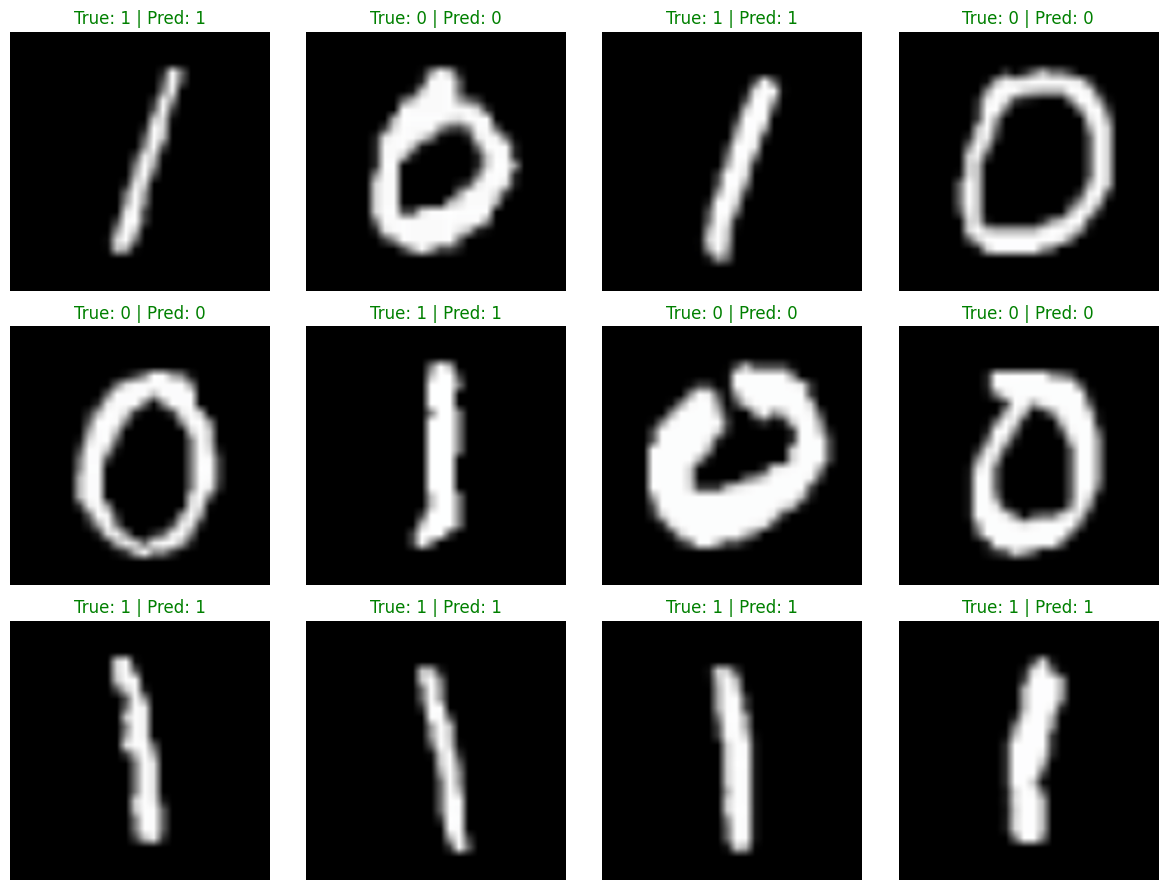

In [28]:
# Определим средние и стандартные отклонения для нормализации ImageNet
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

model_ft.eval()
with torch.no_grad():
    outputs = model_ft(images)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(3, 4, figsize=(12,9))
for idx, ax in enumerate(axes.flat):
    if idx >= len(images):
        break
    img = images[idx].cpu()
    label = labels[idx].item()
    pred = preds[idx].item()
    title = f'True: {label} | Pred: {pred}'

    # Преобразуем тензор (C, H, W) в (H, W, C) для отображения
    img_disp = img.numpy().transpose((1, 2, 0))
    # Денормализация: было (x - mean)/std -> обратно x = img_disp * std + mean
    img_disp = std * img_disp + mean
    img_disp = np.clip(img_disp, 0, 1)  # обрезаем значения за пределами [0,1]

    ax.imshow(img_disp)
    ax.set_title(title, color='green' if label == pred else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Дополнительно: обучение модели с нуля для сравнения

Чтобы убедиться в эффективности Transfer Learning, обучим такую же архитектуру ResNet-18, но со случайной инициализацией, на нашем подмножестве MNIST (цифры 0 и 1).

In [29]:
model_scratch = models.resnet18(weights=None, num_classes=2).to(device)
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=1e-3)
scheduler_scratch = optim.lr_scheduler.StepLR(optimizer_scratch, step_size=7, gamma=0.1)

model_scratch, history_scratch = train_model(model_scratch, train_loader, test_loader, criterion, optimizer_scratch, epochs=5, scheduler=scheduler_scratch)

print(f"Лучшая точность обучения с нуля: {max(history_scratch['test_acc']):.4f}")


Эпоха 1/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0234 Acc: 0.9921
Test Loss: 0.0033 Acc: 0.9991

Эпоха 2/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0094 Acc: 0.9967
Test Loss: 0.0433 Acc: 0.9915

Эпоха 5/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0122 Acc: 0.9965
Test Loss: 0.0178 Acc: 0.9953

Лучшая точность на тесте: 0.9991
Лучшая точность обучения с нуля: 0.9991


## 10. Общий график сравнения трёх подходов

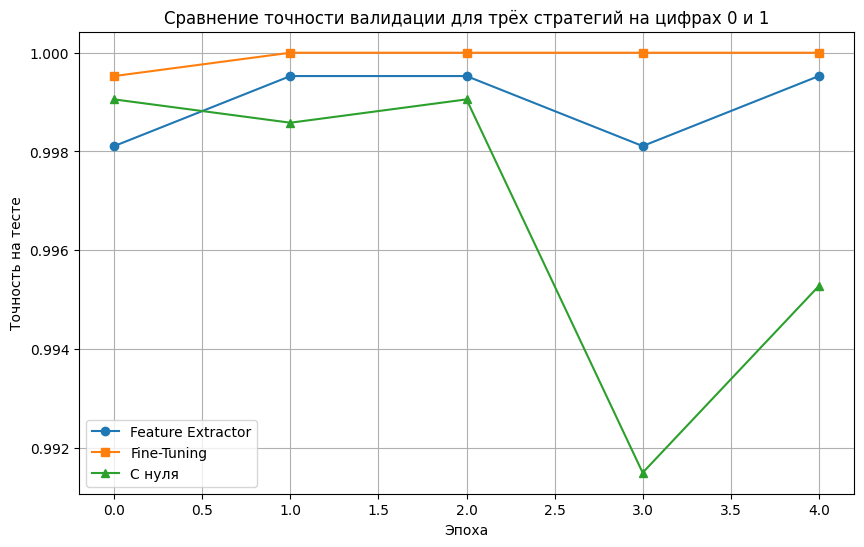

In [30]:
plt.figure(figsize=(10,6))
plt.plot(history_fe['test_acc'], label='Feature Extractor', marker='o')
plt.plot(history_ft['test_acc'], label='Fine-Tuning', marker='s')
plt.plot(history_scratch['test_acc'], label='С нуля', marker='^')
plt.xlabel('Эпоха')
plt.ylabel('Точность на тесте')
plt.title('Сравнение точности валидации для трёх стратегий на цифрах 0 и 1')
plt.legend()
plt.grid(True)
plt.show()

## 11. Выводы

- **Feature Extractor** (обучение только классификатора) уже даёт неплохое качество (~99%+) благодаря мощным низкоуровневым признакам, выученным на ImageNet (края, текстуры), которые оказались полезны даже для распознавания рукописных цифр — задачи, совершенно отсутствующей в ImageNet.
- **Fine-Tuning** (дообучение всех слоёв) позволяет дополнительно улучшить результат (часто до 100%), адаптируя предобученные признаки под специфику цифр.
- **Обучение с нуля** на этом же датасете также даёт высокую точность, но требует больше эпох и данных; Transfer Learning позволяет достичь отличных результатов быстрее и с меньшими вычислительными затратами.

Таким образом, Transfer Learning остаётся мощным инструментом даже когда новый домен сильно отличается от исходного, благодаря универсальности ранних слоёв нейросети.

**Заключение:**
1. Увеличилась ли эффективность модели за теже самые вычислительные ресурсы?
2. Новые навыки/умения/знания.
3. Пожелания по наполнению лекции и практики.

Эффектиность увеличилась